In [25]:
import SimDAT2D.SimDAT2D_MDK as sim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import IsoDAT2D.IsoDAT2D_MDK as iso
from PIL import Image
import pyFAI, fabio
from pyFAI.gui import jupyter
import pyFAI
import os
import matplotlib.pyplot as plt
from tifffile import imread
from SimDAT2D import masking
import pyFAI.azimuthalIntegrator as AI

In [36]:
# # to reload any iterative changes to the code, uncomment the following lines:
import importlib
sim = importlib.reload(sim)
iso = importlib.reload(iso)

Select calibrant:
1. AgBh
2. Al
3. alpha_Al2O3
4. Au
5. C14H30O
6. CeO2
7. Cr2O3
8. cristobaltite
9. CrOx
10. CuO
11. hydrocerussite
12. LaB6
13. LaB6_SRM660a
14. LaB6_SRM660b
15. LaB6_SRM660c
16. mock
17. NaCl
18. Ni
19. PBBA
20. Pt
21. quartz
22. Si
23. Si_SRM640
24. Si_SRM640a
25. Si_SRM640b
26. Si_SRM640c
27. Si_SRM640d
28. Si_SRM640e
29. TiO2
30. ZnO
Ni


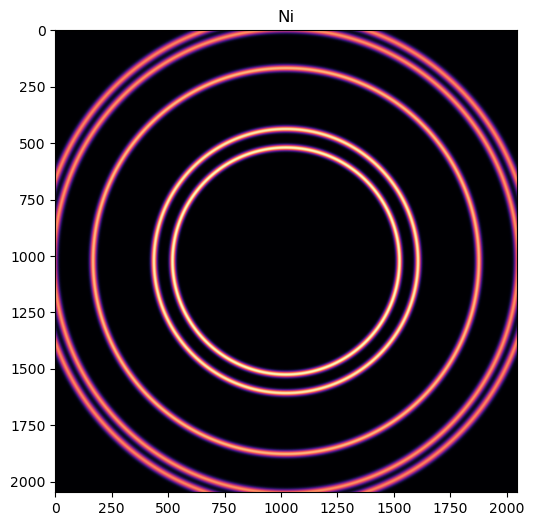

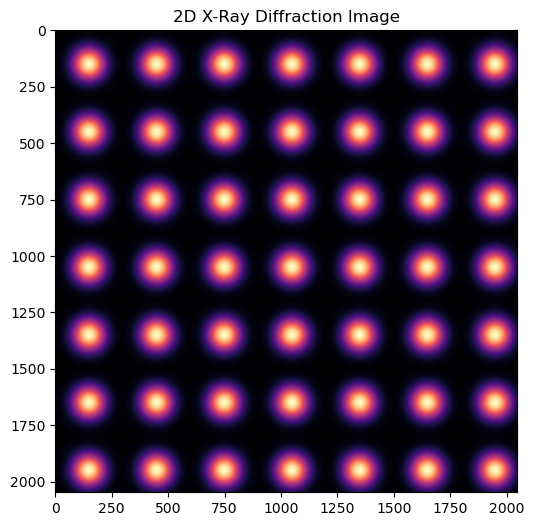

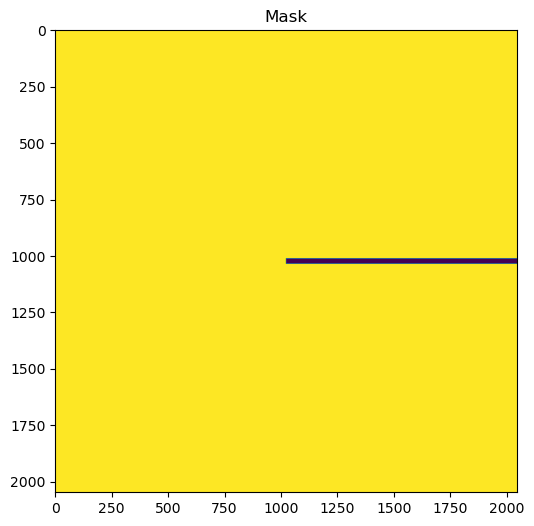

In [3]:
thin_film = sim.create_isotropic(.4, .5e-10, cmap = 'magma')
substrate = sim.create_anisotropic(25, 50, 300, 300, cmap = 'magma')
mask12 = sim.create_mask(thin_film, 12)

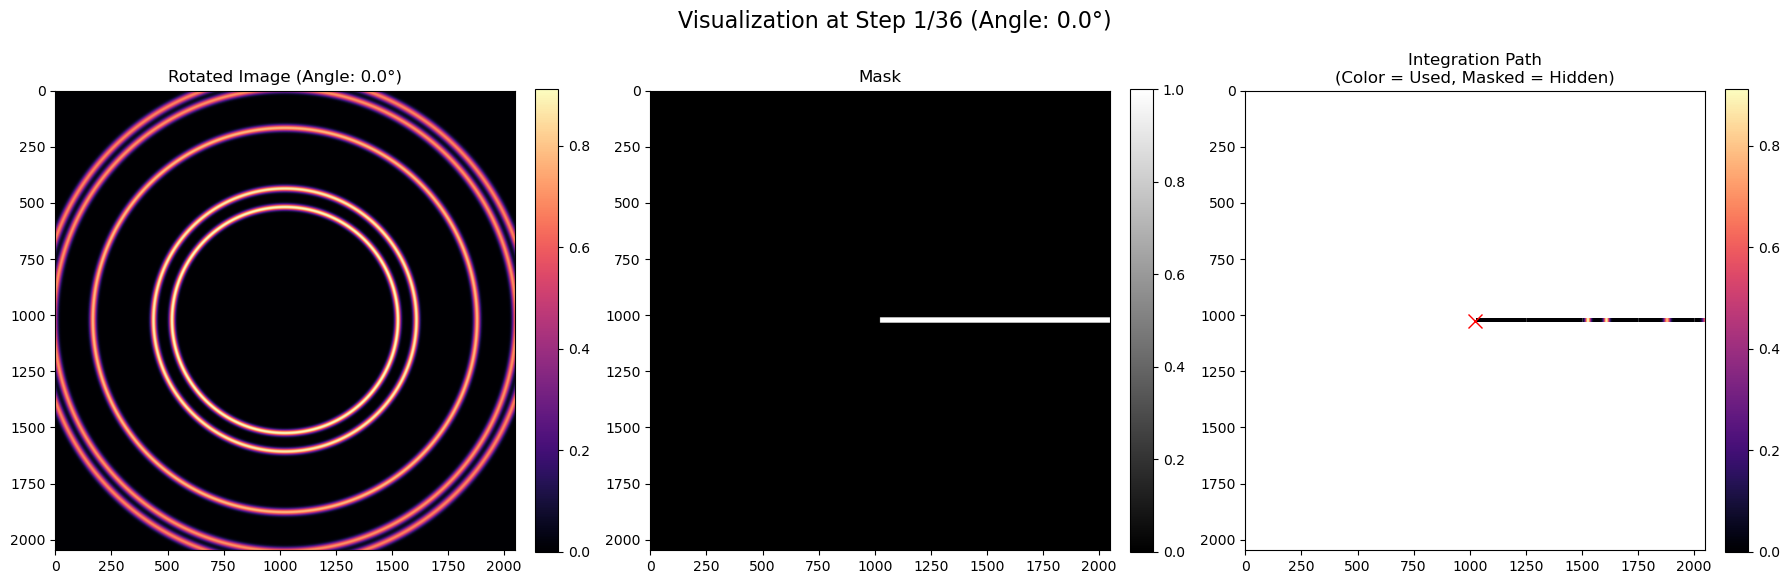

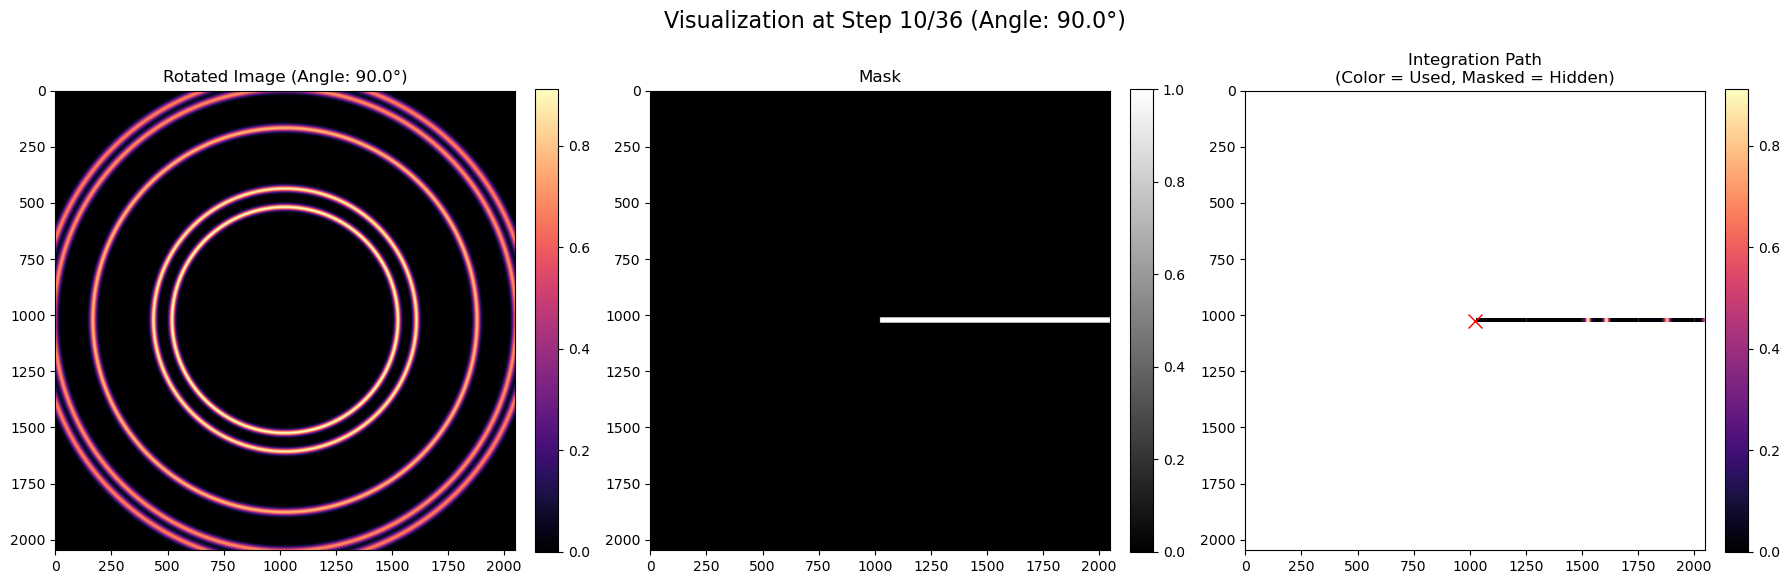

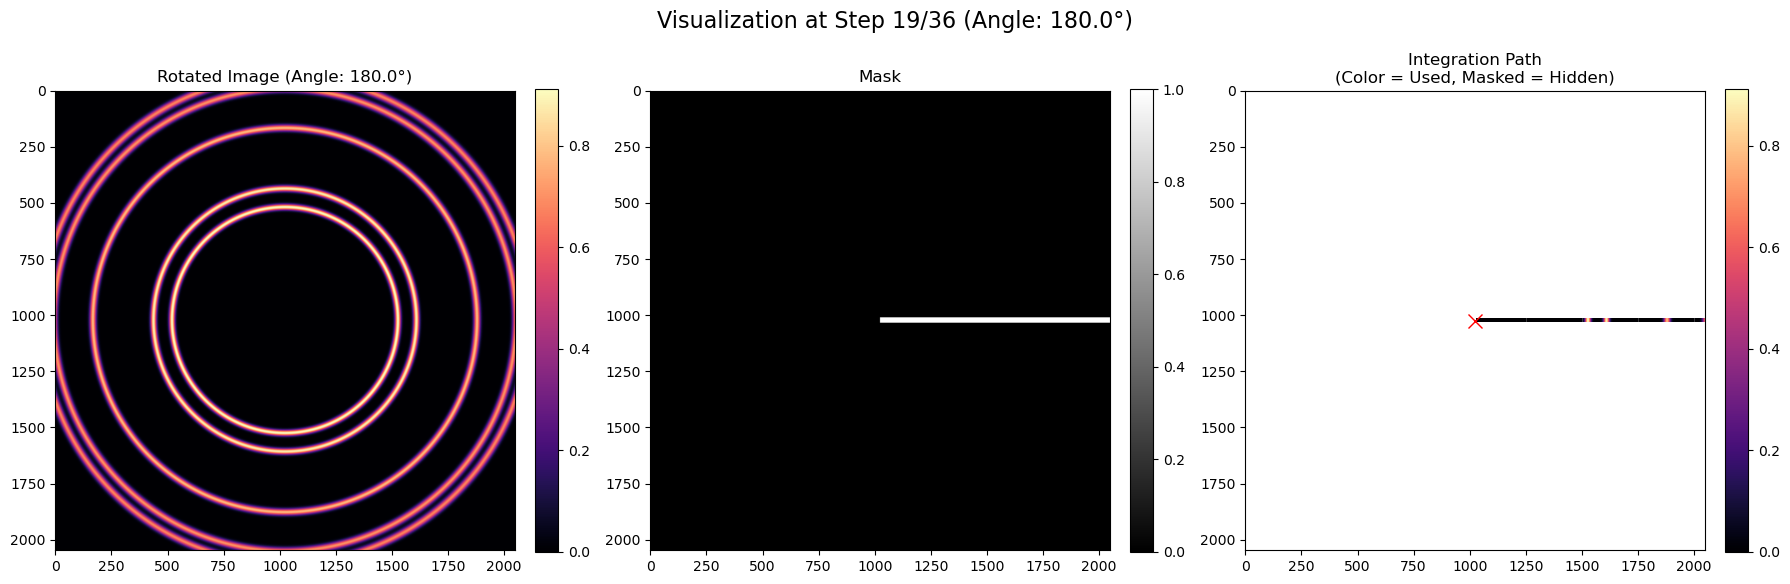

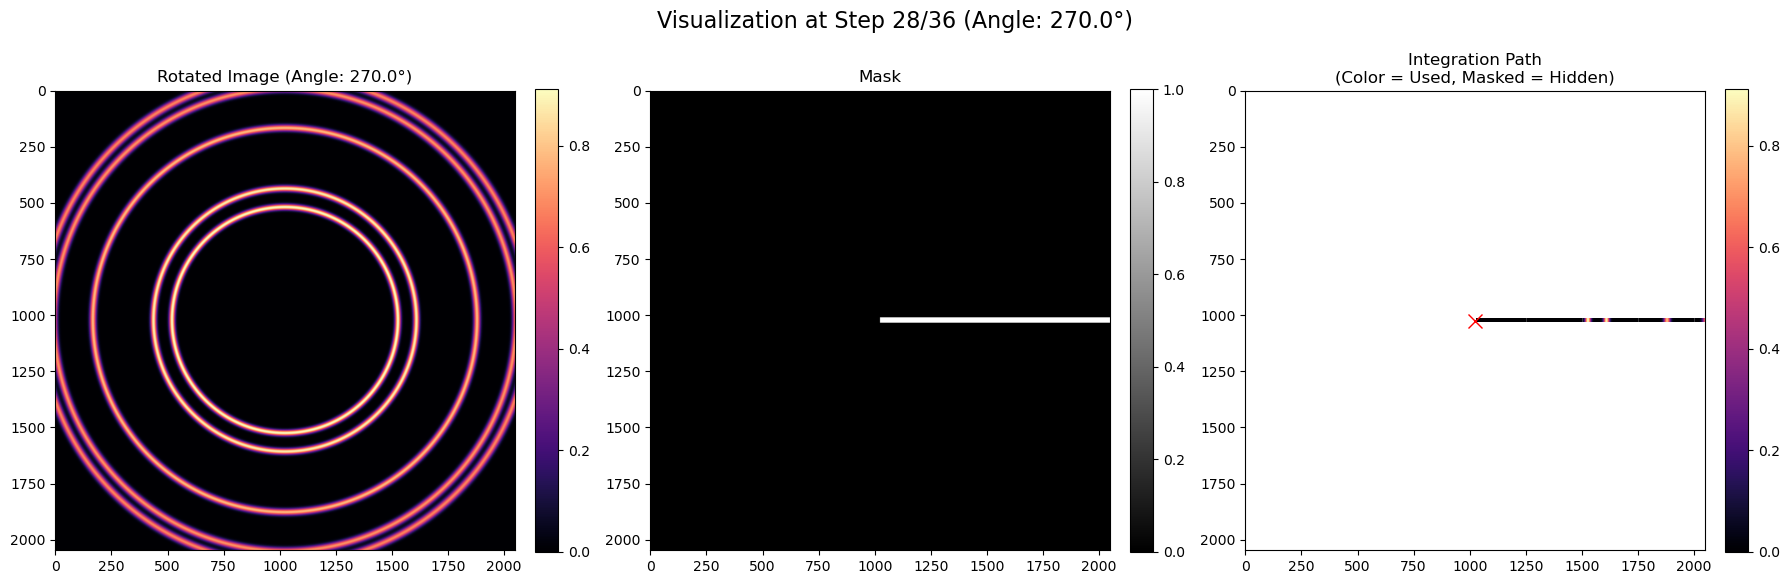

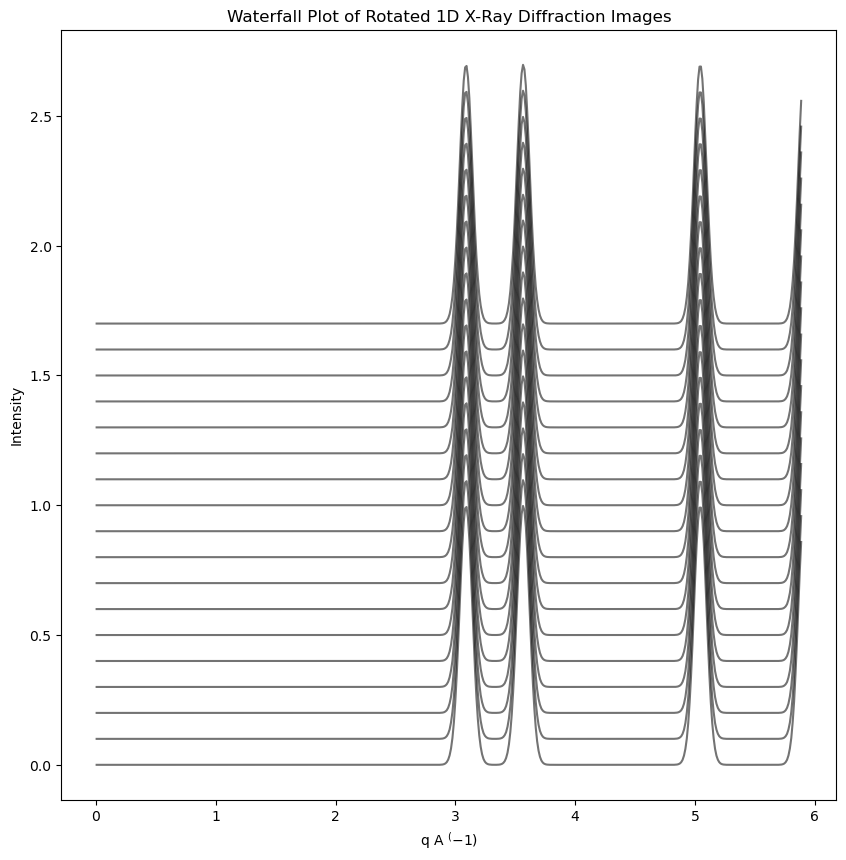

In [4]:
q, iso_data = sim.rotate_and_integrate_printout(thin_film, 10, .4, .5e-10, resolution = 500, mask = mask12, vis_interval = 9, source_label='isotropic')

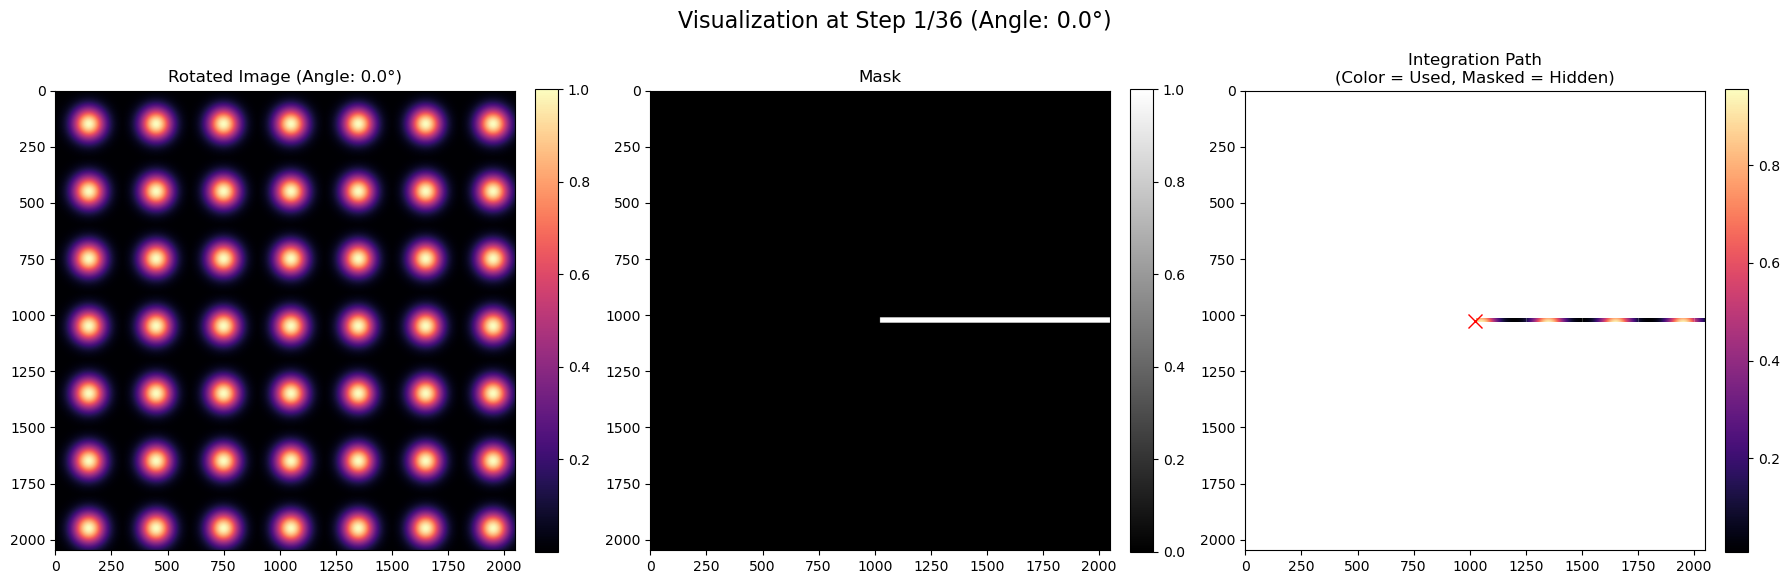

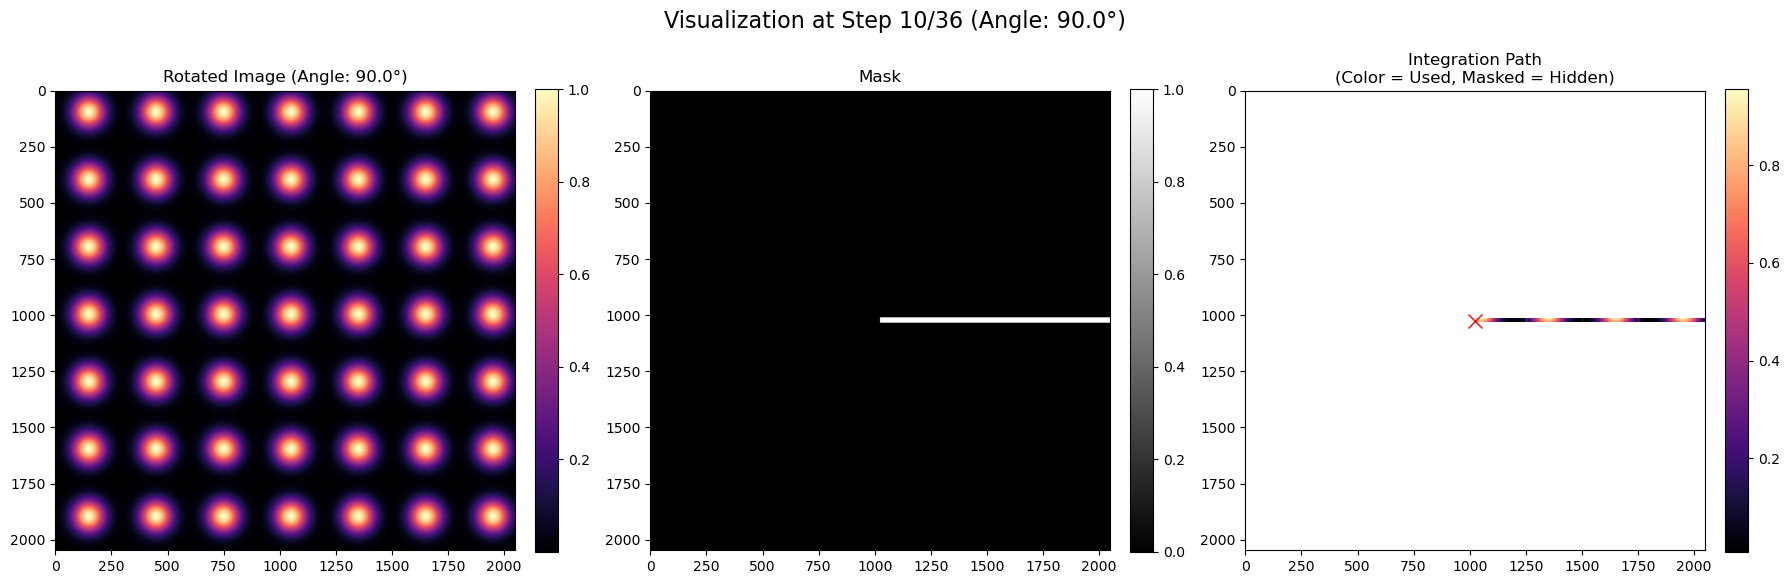

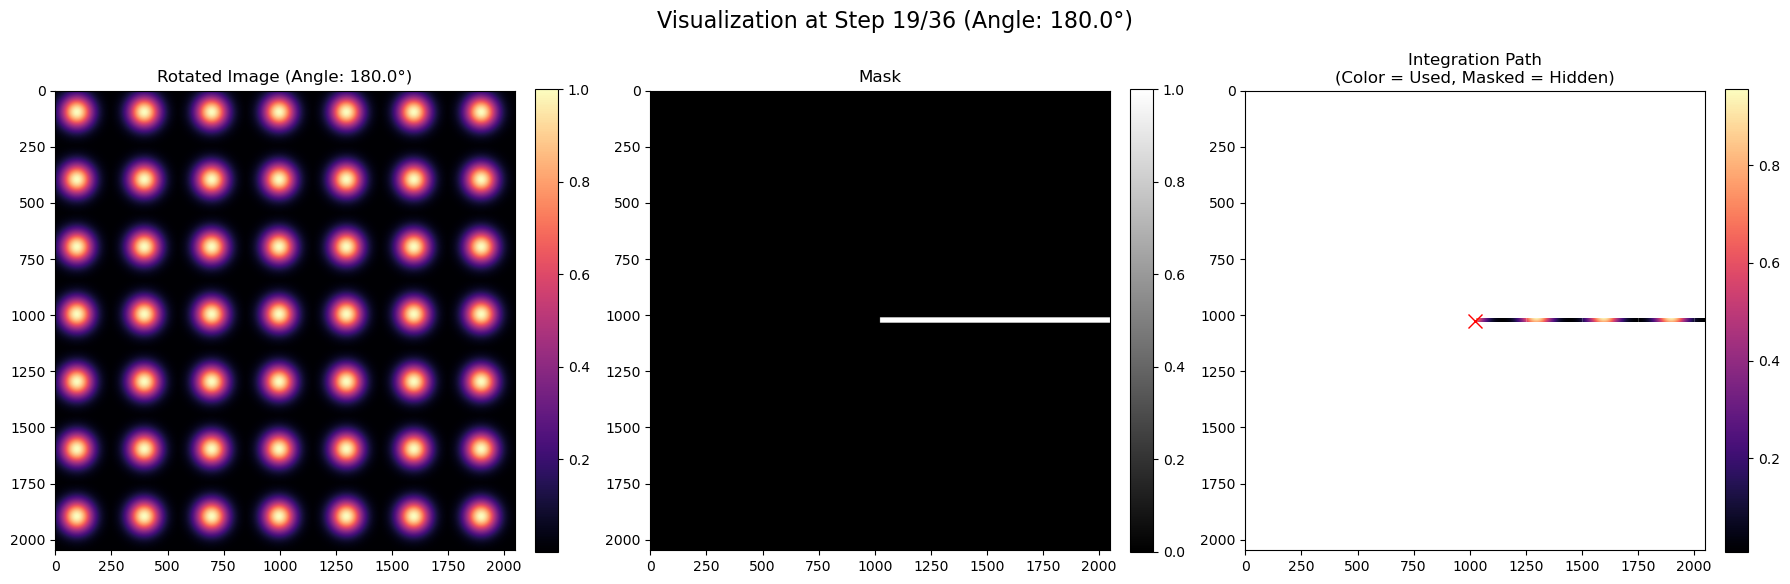

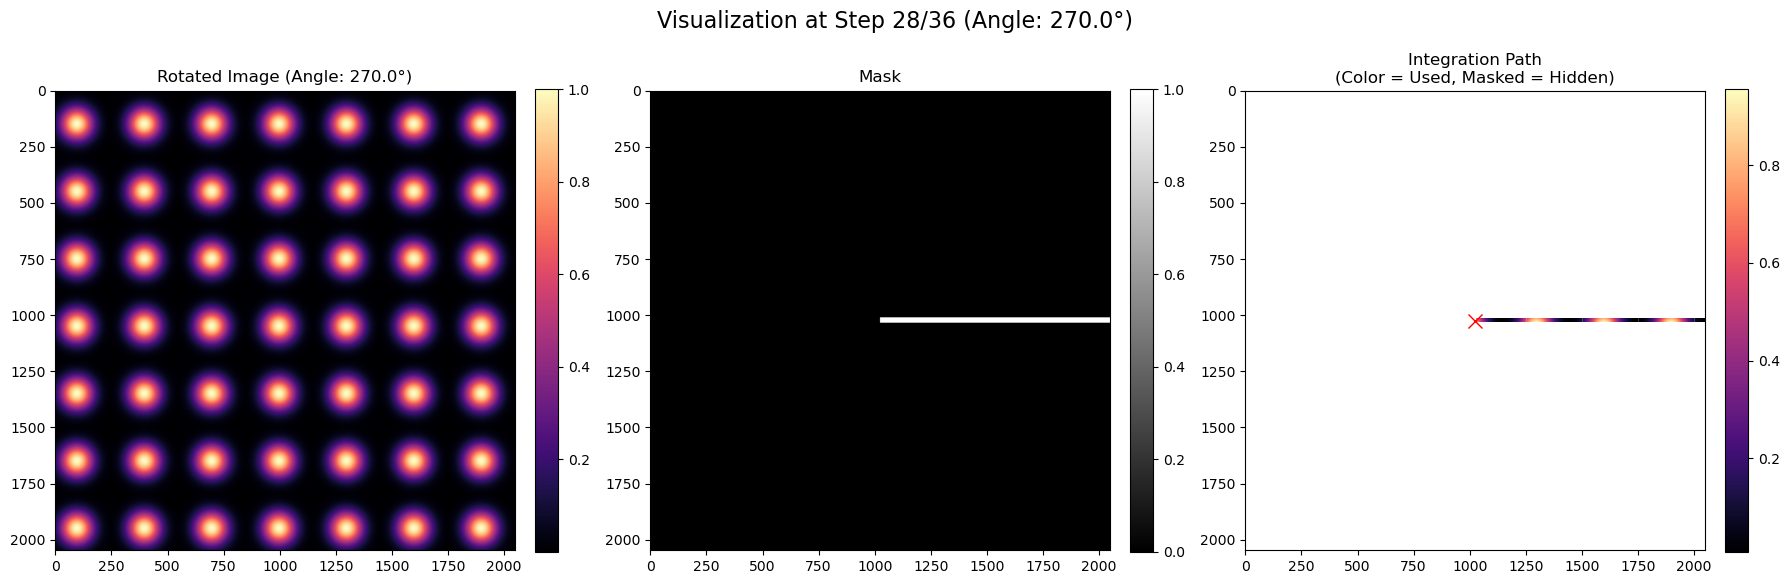

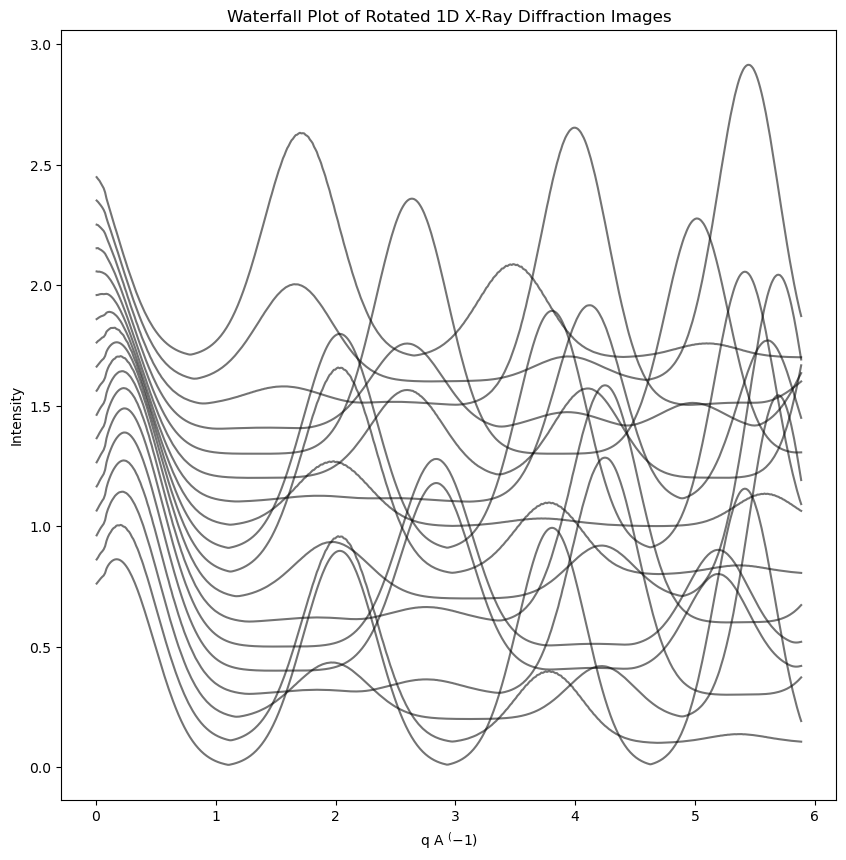

In [5]:
q, aniso_data = sim.rotate_and_integrate_printout(substrate, 10, .4, .5e-10, resolution = 500, mask = mask12, vis_interval = 9, source_label="anisotropic")

In [6]:
print(aniso_data)

    anisotropic                                                              \
          0.000    10.000    20.000    30.000    40.000    50.000    60.000   
0      0.761924  0.761924  0.761954  0.764880  0.764934  0.764935  0.764881   
1      0.769261  0.770427  0.773094  0.775086  0.774602  0.775353  0.775087   
2      0.776916  0.781010  0.783864  0.786251  0.786873  0.786956  0.786252   
3      0.783909  0.789375  0.793636  0.796401  0.797600  0.797601  0.796402   
4      0.790047  0.795776  0.802145  0.805827  0.807282  0.807400  0.805829   
..          ...       ...       ...       ...       ...       ...       ...   
495    0.270923  0.008202  1.130613  0.049692  0.017461  0.017466  0.049692   
496    0.249472  0.007599  1.097360  0.054932  0.017460  0.017460  0.054932   
497    0.228883  0.007146  1.063418  0.060411  0.017976  0.017972  0.060411   
498    0.209286  0.006657  1.027041  0.066655  0.018990  0.018997  0.066655   
499    0.191722  0.006191  0.991362  0.072809  0.020

In [7]:
cluster_aniso_data = aniso_data.T
print(cluster_aniso_data)

                          0         1         2         3         4    \
anisotropic 0.000    0.761924  0.769261  0.776916  0.783909  0.790047   
            10.000   0.761924  0.770427  0.781010  0.789375  0.795776   
            20.000   0.761954  0.773094  0.783864  0.793636  0.802145   
            30.000   0.764880  0.775086  0.786251  0.796401  0.805827   
            40.000   0.764934  0.774602  0.786873  0.797600  0.807282   
            50.000   0.764935  0.775353  0.786956  0.797601  0.807400   
            60.000   0.764881  0.775087  0.786252  0.796402  0.805829   
            70.000   0.761956  0.773096  0.784017  0.793661  0.802005   
            80.000   0.761927  0.770430  0.781292  0.789414  0.795952   
            90.000   0.761927  0.769264  0.776919  0.783913  0.790051   
            100.000  0.761927  0.768031  0.772060  0.777545  0.782447   
            110.000  0.758917  0.763137  0.767033  0.770222  0.772482   
            120.000  0.758805  0.759605  0.761668  

In [8]:
print(aniso_data.columns.get_level_values(0))  # This will show just the source labels
print(aniso_data.columns.get_level_values(1))  # This will show just the angle labels

Index(['anisotropic', 'anisotropic', 'anisotropic', 'anisotropic',
       'anisotropic', 'anisotropic', 'anisotropic', 'anisotropic',
       'anisotropic', 'anisotropic', 'anisotropic', 'anisotropic',
       'anisotropic', 'anisotropic', 'anisotropic', 'anisotropic',
       'anisotropic', 'anisotropic', 'anisotropic', 'anisotropic',
       'anisotropic', 'anisotropic', 'anisotropic', 'anisotropic',
       'anisotropic', 'anisotropic', 'anisotropic', 'anisotropic',
       'anisotropic', 'anisotropic', 'anisotropic', 'anisotropic',
       'anisotropic', 'anisotropic', 'anisotropic', 'anisotropic'],
      dtype='object')
Index(['0.000', '10.000', '20.000', '30.000', '40.000', '50.000', '60.000',
       '70.000', '80.000', '90.000', '100.000', '110.000', '120.000',
       '130.000', '140.000', '150.000', '160.000', '170.000', '180.000',
       '190.000', '200.000', '210.000', '220.000', '230.000', '240.000',
       '250.000', '260.000', '270.000', '280.000', '290.000', '300.000',
       '3

In [9]:
print(aniso_data)

    anisotropic                                                              \
          0.000    10.000    20.000    30.000    40.000    50.000    60.000   
0      0.761924  0.761924  0.761954  0.764880  0.764934  0.764935  0.764881   
1      0.769261  0.770427  0.773094  0.775086  0.774602  0.775353  0.775087   
2      0.776916  0.781010  0.783864  0.786251  0.786873  0.786956  0.786252   
3      0.783909  0.789375  0.793636  0.796401  0.797600  0.797601  0.796402   
4      0.790047  0.795776  0.802145  0.805827  0.807282  0.807400  0.805829   
..          ...       ...       ...       ...       ...       ...       ...   
495    0.270923  0.008202  1.130613  0.049692  0.017461  0.017466  0.049692   
496    0.249472  0.007599  1.097360  0.054932  0.017460  0.017460  0.054932   
497    0.228883  0.007146  1.063418  0.060411  0.017976  0.017972  0.060411   
498    0.209286  0.006657  1.027041  0.066655  0.018990  0.018997  0.066655   
499    0.191722  0.006191  0.991362  0.072809  0.020

In [10]:
print(iso_data.columns.get_level_values(0)) 
print(iso_data.columns.get_level_values(1))

Index(['isotropic', 'isotropic', 'isotropic', 'isotropic', 'isotropic',
       'isotropic', 'isotropic', 'isotropic', 'isotropic', 'isotropic',
       'isotropic', 'isotropic', 'isotropic', 'isotropic', 'isotropic',
       'isotropic', 'isotropic', 'isotropic', 'isotropic', 'isotropic',
       'isotropic', 'isotropic', 'isotropic', 'isotropic', 'isotropic',
       'isotropic', 'isotropic', 'isotropic', 'isotropic', 'isotropic',
       'isotropic', 'isotropic', 'isotropic', 'isotropic', 'isotropic',
       'isotropic'],
      dtype='object')
Index(['0.000', '10.000', '20.000', '30.000', '40.000', '50.000', '60.000',
       '70.000', '80.000', '90.000', '100.000', '110.000', '120.000',
       '130.000', '140.000', '150.000', '160.000', '170.000', '180.000',
       '190.000', '200.000', '210.000', '220.000', '230.000', '240.000',
       '250.000', '260.000', '270.000', '280.000', '290.000', '300.000',
       '310.000', '320.000', '330.000', '340.000', '350.000'],
      dtype='object')


In [11]:
print(iso_data)

    isotropic                                                              \
        0.000    10.000    20.000    30.000    40.000    50.000    60.000   
0    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
3    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
..        ...       ...       ...       ...       ...       ...       ...   
495  0.351458  0.352624  0.350970  0.349902  0.350351  0.351653  0.350008   
496  0.473225  0.472333  0.476273  0.476263  0.473917  0.473957  0.476384   
497  0.608165  0.610563  0.608014  0.604928  0.606856  0.608274  0.605053   
498  0.743864  0.741816  0.744745  0.747546  0.743046  0.744587  0.747663   
499  0.858465  0.858031  0.858199  0.858818  0.857529  0.858263  0.858914   

In [12]:
cluster_iso_data = iso_data.T
print(cluster_iso_data)

                   0    1    2    3    4    5    6    7    8    9    ...  \
isotropic 0.000    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          10.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          20.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          30.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          40.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          50.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          60.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          70.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          80.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          90.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          100.000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          110.000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
          12

In [13]:
#first try appending one to the end of the other
comb_data = pd.concat([cluster_iso_data, cluster_aniso_data], axis=1)

In [14]:
stacked = pd.concat(
    [cluster_iso_data, cluster_aniso_data], axis=0,
    join='inner'          # only keep q-values (columns) present in both
)
print(stacked)


                          0         1         2         3         4    \
isotropic   0.000    0.000000  0.000000  0.000000  0.000000  0.000000   
            10.000   0.000000  0.000000  0.000000  0.000000  0.000000   
            20.000   0.000000  0.000000  0.000000  0.000000  0.000000   
            30.000   0.000000  0.000000  0.000000  0.000000  0.000000   
            40.000   0.000000  0.000000  0.000000  0.000000  0.000000   
...                       ...       ...       ...       ...       ...   
anisotropic 310.000  0.752948  0.752777  0.749207  0.746291  0.741993   
            320.000  0.756768  0.754701  0.755784  0.754232  0.752397   
            330.000  0.758800  0.759601  0.761663  0.762926  0.763213   
            340.000  0.758914  0.763133  0.767171  0.770331  0.772605   
            350.000  0.761924  0.768026  0.771831  0.777513  0.782269   

                          5         6         7         8         9    ...  \
isotropic   0.000    0.000000  0.000000  0.00

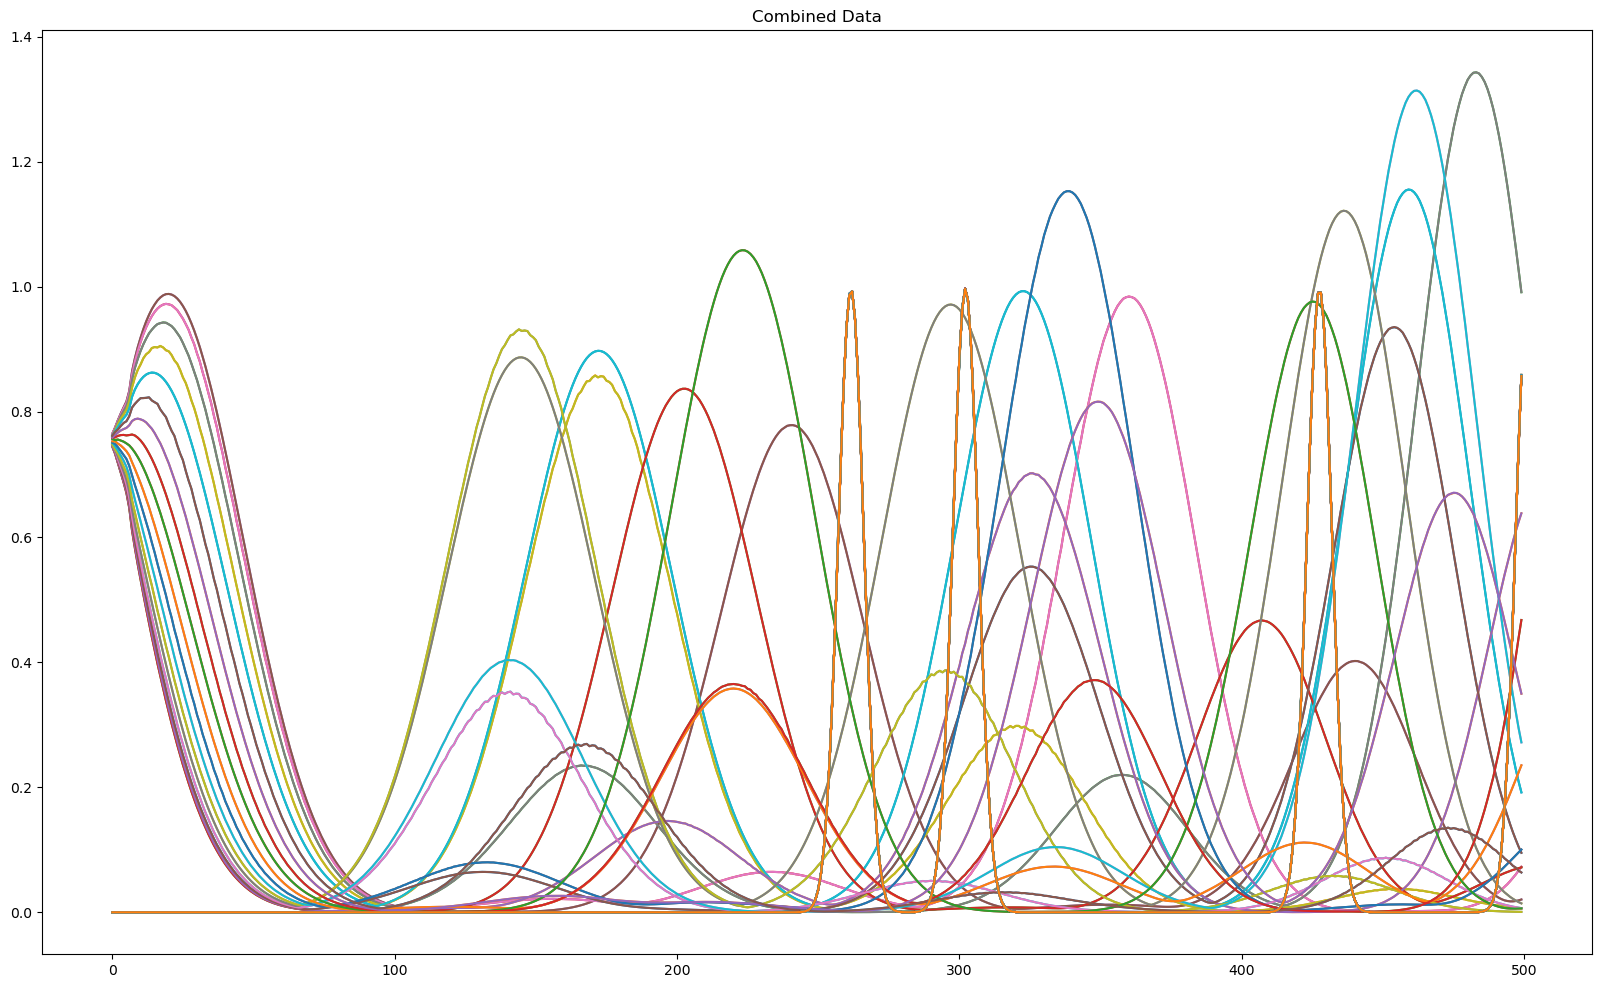

In [49]:
plt.figure(figsize=(20,12))
# Iterate over each group in the MultiIndex DataFrame
for name, group in stacked.groupby(level=0):
    # Plot each row in the group
    for index, row in group.iterrows():
        plt.plot(row.index, row.values, label=f"{name} {index[1]}")


plt.title('Combined Data')
# plt.legend(loc='upper right', fontsize='small', ncol=2)  # Adjust legend as needed
plt.show()

In [15]:
print(comb_data)

                     0    1    2    3    4    5    6    7    8    9    ...  \
isotropic   0.000    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
            10.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
            20.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
            30.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
            40.000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
...                  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
anisotropic 310.000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
            320.000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
            330.000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
            340.000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
            350.000  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   

                          490       491       492       493    

In [16]:
def analyze_cluster_compositions(Understanding_data, data_labels):
    """
    Analyze the composition of each cluster in terms of isotropic vs anisotropic contributions.
    
    Parameters:
    Understanding_data: Dictionary containing cluster assignments and data points
    data_labels: List of labels ('isotropic' or 'anisotropic') for each data point
    
    Returns:
    Dictionary containing composition analysis for each cluster
    """
    # Get unique cluster numbers
    unique_clusters = set(Understanding_data["Cluster_Number"])
    
    # Initialize results dictionary
    cluster_compositions = {}
    
    # Get the actual data points for each cluster
    cluster_data = Understanding_data["Int_Angle"]
    
    # Analyze each cluster
    for cluster in unique_clusters:
        # Get indices of data points in this cluster
        cluster_indices = [i for i, x in enumerate(Understanding_data["Cluster_Number"]) if x == cluster]
        
        # Count isotropic and anisotropic contributions
        isotropic_count = sum(1 for i in cluster_indices if i < len(data_labels['isotropic']))
        anisotropic_count = sum(1 for i in cluster_indices if i < len(data_labels['anisotropic']))
        total_count = len(cluster_indices)
        
        # Calculate percentages
        isotropic_percent = (isotropic_count / total_count) * 100 if total_count > 0 else 0
        anisotropic_percent = (anisotropic_count / total_count) * 100 if total_count > 0 else 0
        
        # Store results
        cluster_compositions[cluster] = {
            'total_points': total_count,
            'isotropic_count': isotropic_count,
            'anisotropic_count': anisotropic_count,
            'isotropic_percent': isotropic_percent,
            'anisotropic_percent': anisotropic_percent
        }
    
    return cluster_compositions

# Function to print the analysis results
def print_cluster_analysis(cluster_compositions):
    """
    Print a formatted analysis of cluster compositions.
    """
    print("\nCluster Composition Analysis:")
    print("-" * 50)
    for cluster, comp in cluster_compositions.items():
        print(f"\nCluster {cluster}:")
        print(f"Total points: {comp['total_points']}")
        print(f"Isotropic contributions: {comp['isotropic_count']} ({comp['isotropic_percent']:.1f}%)")
        print(f"Anisotropic contributions: {comp['anisotropic_count']} ({comp['anisotropic_percent']:.1f}%)")

AgglomerativeClustering(compute_distances=True)


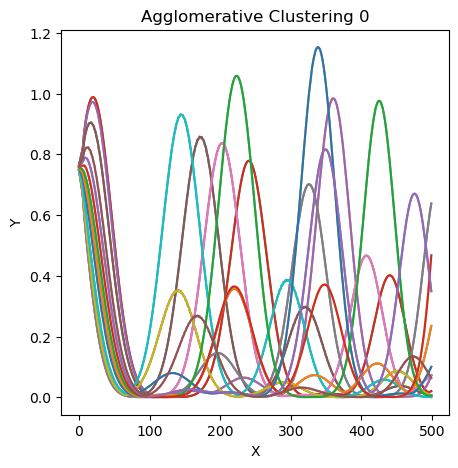

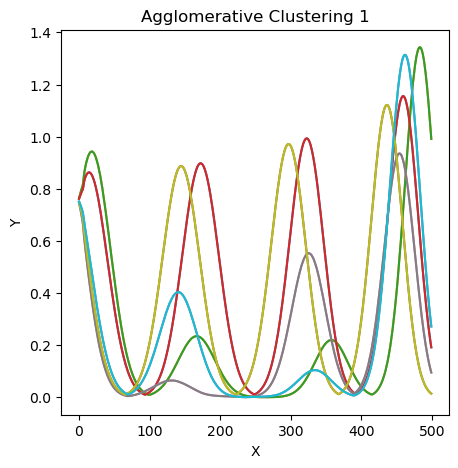

In [17]:
Number_Clusters = 2
understanding_data, data_list = iso.AggCluster(2, cluster_aniso_data)

AgglomerativeClustering(compute_distances=True)


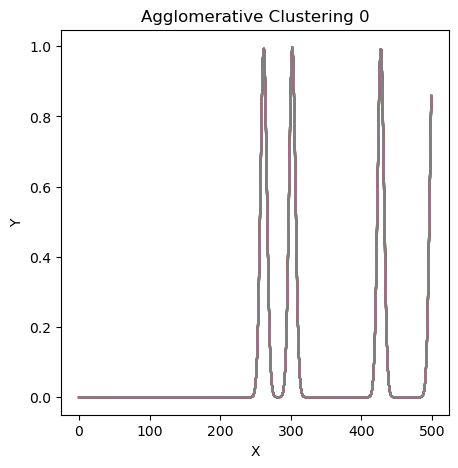

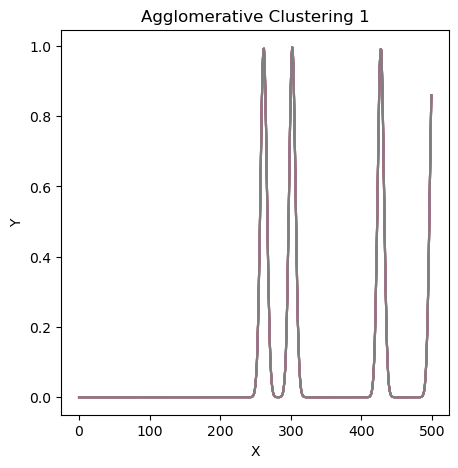

In [18]:
Number_Clusters = 2
understanding_data, data_list = iso.AggCluster(2, cluster_iso_data)

AgglomerativeClustering(compute_distances=True, n_clusters=3)


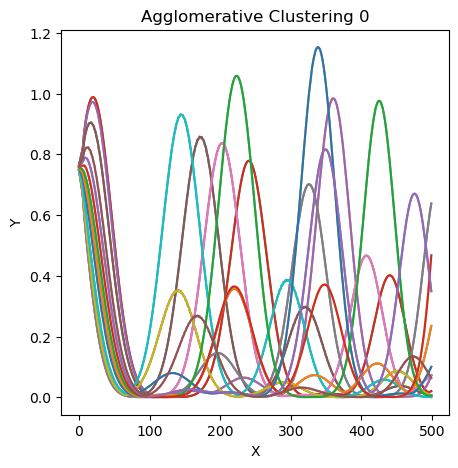

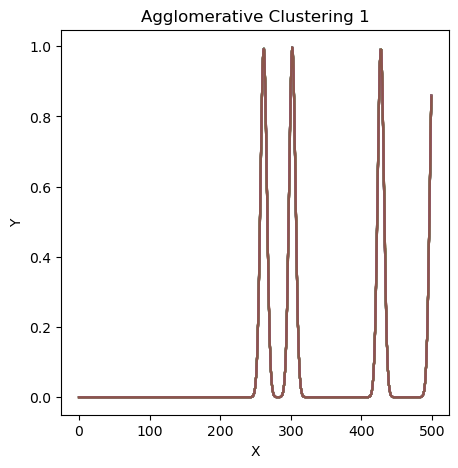

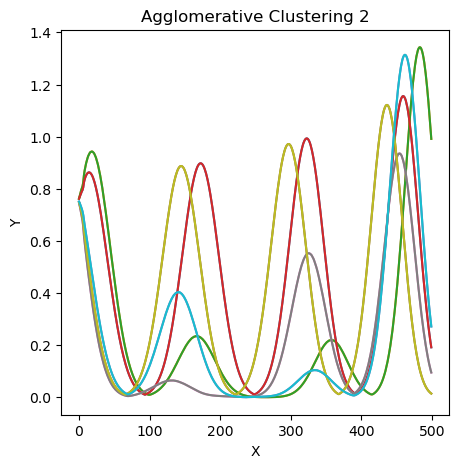

In [19]:
Number_Clusters = 3
understanding_data_stacked, data_list_stacked = iso.AggCluster(3, stacked)

In [20]:
print(understanding_data)

{'Cluster_Number': [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0], 'Int_Angle': [array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
     

In [21]:
print(data_list)

[array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
     

In [22]:
print(understanding_data_stacked)

{'Cluster_Number': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0], 'Int_Angle': [array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 

[array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
     

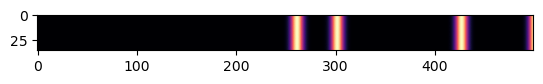

In [ ]:
print(data_list_stacked)
plt.imshow(data_list_stacked, cmap = 'magma')
plt.show()

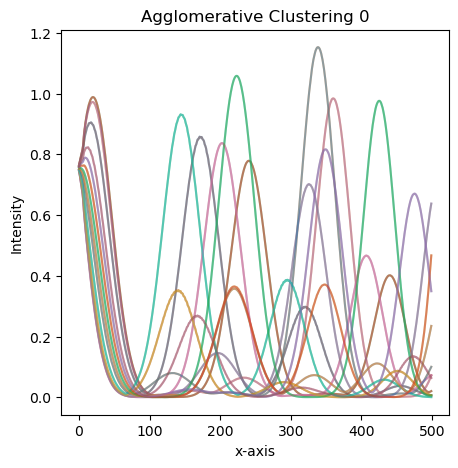

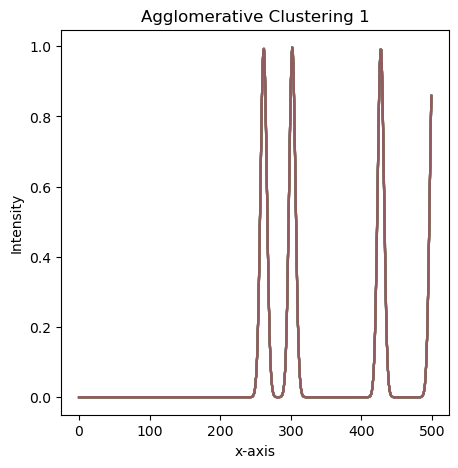

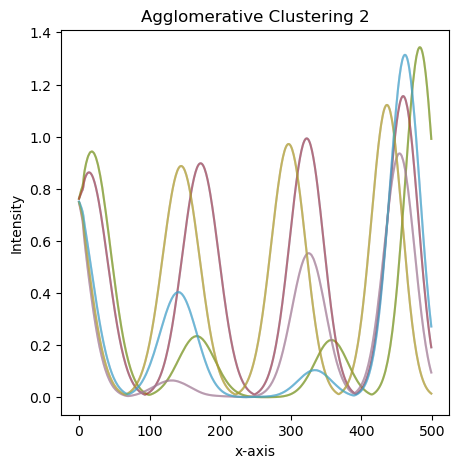

In [ ]:
u_data_stacked_label, data_list_stacked_label = iso.AggCluster_labels(3, stacked)

Pull labels back from clusters-- how many entries in each cluster are isotropic?

In [33]:
u_data_stacked_label.query("type=='isotropic' and cluster==0").shape[0]

0

In [34]:
u_data_stacked_label.query("type=='isotropic' and cluster==1").shape[0]

36

In [32]:

u_data_stacked_label.query("type=='isotropic' and cluster==2").shape[0]

0